In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.animation as animation
from geopy.geocoders import Nominatim
from time import sleep
import pandas as pd

In [2]:
# Skip the data-processing
processed_ds = xr.open_dataset("/data/keeling/a/alison8/AlisonCapstone/wrf_framinputs_14dec2024_wSR.nc")
processed_ds

<xarray.Dataset> Size: 198MB
Dimensions:      (time: 97, south_north: 319, west_east: 319)
Coordinates:
  * time         (time) datetime64[ns] 776B 2024-12-14 ... 2024-12-16
    XLAT         (south_north, west_east) float32 407kB ...
    XLONG        (south_north, west_east) float32 407kB ...
Dimensions without coordinates: south_north, west_east
Data variables:
    precip_rate  (time, south_north, west_east) float32 39MB ...
    SR           (time, south_north, west_east) float32 39MB ...
    wind_speed   (time, south_north, west_east) float32 39MB ...
    wetbulb      (time, south_north, west_east) float64 79MB ...
Attributes:
    description:      WRF-derived FRAM input variables
    time_resolution:  30 minutes
    units:            precip_rate=mm/hr, SR=fraction, wind_speed=m/s, wetbulb...

In [3]:
# Source
# Sanders & Barjenbruch (2016)
# “Analysis of Ice-to-Liquid Ratios during Freezing Rain and the Development of an Ice Accumulation Model”
# FRAM Ice Accretion Calculation (Modified FRAM incorporating mixed-phase precipitation)

# Convert wind speed to knots (FRAM requires knots)
wind_kt = processed_ds.wind_speed * 1.94384

# Regime masks: regression equations were derived separately for three precipitation-rate categories
mask1 = processed_ds.precip_rate < 0.5
mask2 = (processed_ds.precip_rate >= 0.5) & (processed_ds.precip_rate < 2.5)
mask3 = processed_ds.precip_rate >= 2.5

# Initialize ILR
ilr = xr.zeros_like(processed_ds.precip_rate)

# Apply FRAM equations (implemented in vectorized xarray form, though algebraically identical to paper)
ilr = xr.where(mask1, 0.73 - 0.29 * processed_ds.precip_rate - 0.01 * processed_ds.wetbulb + 0.01 * wind_kt, ilr)
ilr = xr.where(mask2, 0.81 - 0.18 * processed_ds.precip_rate - 0.01 * processed_ds.wetbulb + 0.01 * wind_kt, ilr)
ilr = xr.where(mask3, 0.93 - 0.06 * processed_ds.precip_rate - 0.01 * processed_ds.wetbulb + 0.01 * wind_kt, ilr)

# Physical constraints: ILR is bounded between 0 and 1
ilr = ilr.clip(min=0.0, max=1.0)

# The paper applies FRAM only under freezing rain conditions
ilr = xr.where(processed_ds.wetbulb <= 0.0, ilr, 0.0)

# Add ILR to dataset
processed_ds["ILR"] = ilr

# Original FRAM
processed_ds["ice_rate_fram"] = processed_ds.ILR * processed_ds.precip_rate

# Modified FRAM with SR
liquid_fraction = 1.0 - processed_ds.SR
freezing_rain_mask = ((processed_ds.wetbulb <= 0.0) & (processed_ds.SR < 0.5))
processed_ds["ice_rate_modified"] = xr.where(freezing_rain_mask, processed_ds.ILR * processed_ds.precip_rate * liquid_fraction, 0.0)

# Time-integrated Ice Thickness
dt = 0.5  # 30-min timestep

processed_ds["ice_thickness_fram"] = (processed_ds.ice_rate_fram * dt).cumsum(dim="time") # flat ice 
processed_ds["ice_thickness_mod"] = (processed_ds.ice_rate_modified * dt).cumsum(dim="time")

# Convert to inches
MM_TO_IN = 0.0393701
processed_ds["ice_thickness_in_fram"] = processed_ds.ice_thickness_fram * MM_TO_IN
processed_ds["ice_thickness_in_mod"] = processed_ds.ice_thickness_mod *MM_TO_IN
processed_ds["ice_rate_in_hr_fram"] = processed_ds.ice_rate_fram * MM_TO_IN
processed_ds["ice_rate_in_hr_mod"] = processed_ds.ice_rate_modified * MM_TO_IN

# Radial ice (powerline / tree branch equivalent)
processed_ds["radial_ice_thickness_in_fram"] = processed_ds.ice_thickness_in_fram * 0.3939
processed_ds["radial_ice_thickness_in_mod"] = processed_ds.ice_thickness_in_mod * 0.3939

In [4]:
# extra stuff for analysis suite below

def setup_map(ax):
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    counties = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_2_counties',
        scale='10m',
        facecolor='none'
    )
    ax.add_feature(counties, edgecolor='gray', linewidth=0.3)

lats = processed_ds.XLAT
lons = processed_ds.XLONG

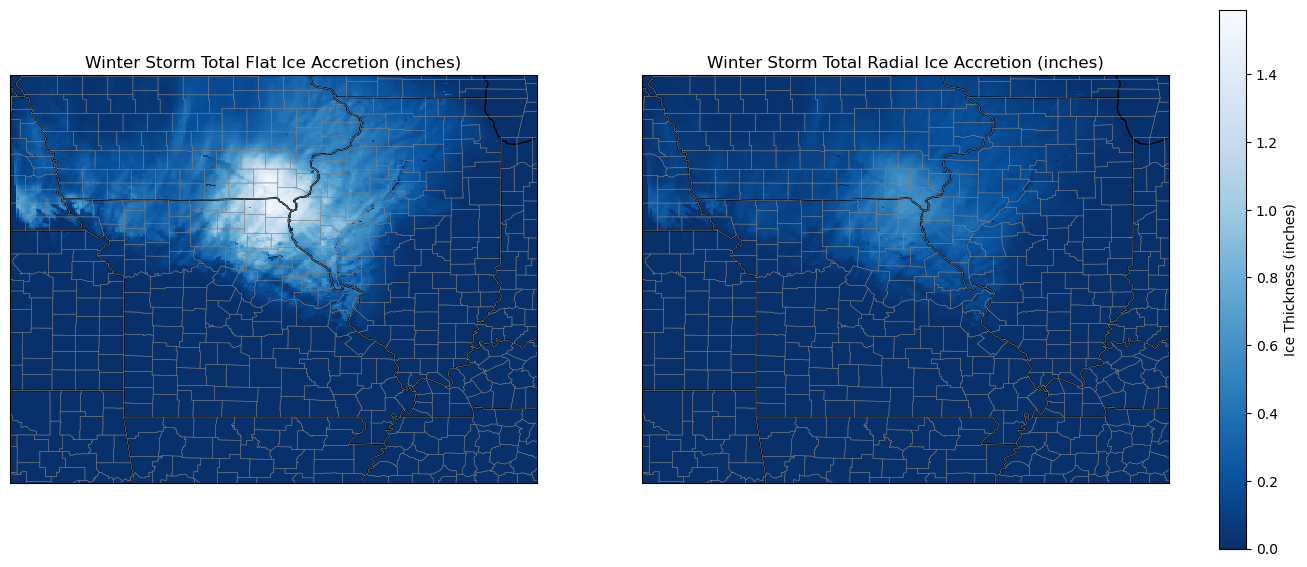

In [5]:
# Storm totals
flat_total = processed_ds.ice_thickness_in_fram.isel(time=-1)
radial_total = processed_ds.radial_ice_thickness_in_fram.isel(time=-1)

# figure
fig, axes = plt.subplots(1, 2, figsize=(16,7), subplot_kw={"projection": ccrs.PlateCarree()})
vmax = float(max(flat_total.max(), radial_total.max()))

# Flat Ice 
mesh1 = axes[0].pcolormesh(lons, lats, flat_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
setup_map(axes[0])
axes[0].set_title("Winter Storm Total Flat Ice Accretion (inches)")
axes[0].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

# Radial Ice
mesh2 = axes[1].pcolormesh(lons, lats, radial_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
setup_map(axes[1])
axes[1].set_title("Winter Storm Total Radial Ice Accretion (inches)")
axes[1].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

cbar = fig.colorbar(mesh1, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
cbar.set_label("Ice Thickness (inches)")
plt.show()

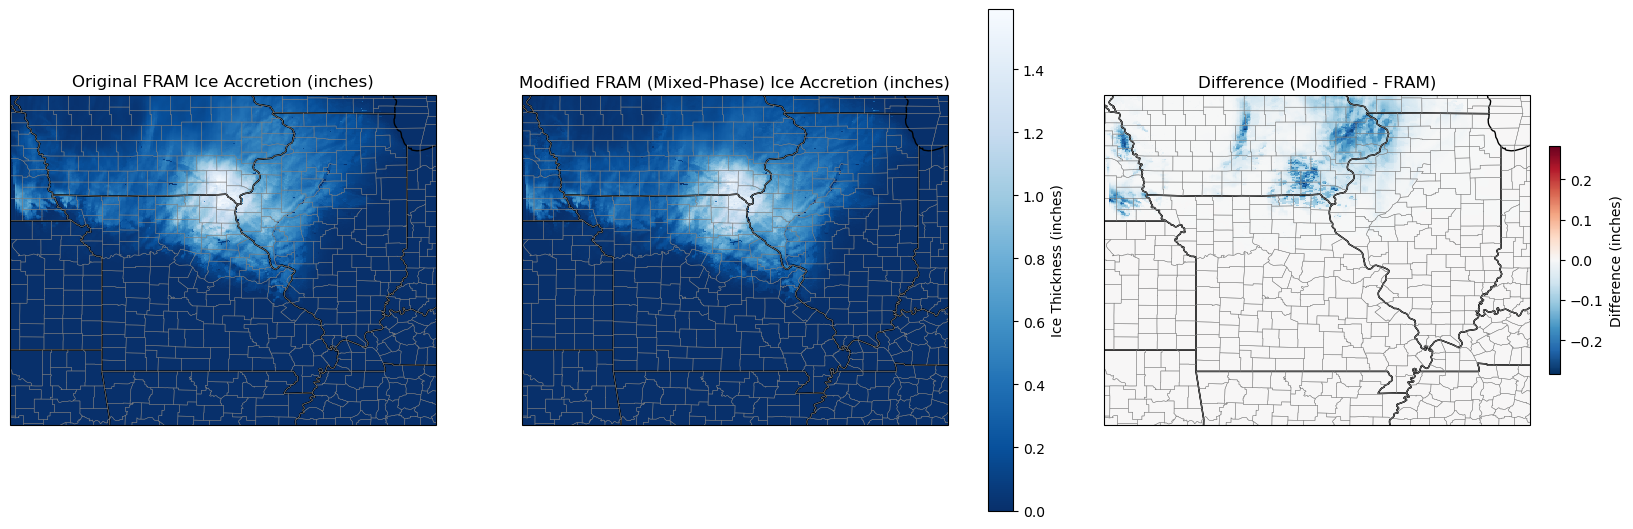

In [6]:
# FRAM vs. modified FRAM
fram_total = processed_ds.ice_thickness_in_fram.isel(time=-1)
mod_total  = processed_ds.ice_thickness_in_mod.isel(time=-1)

diff = mod_total - fram_total
fig, axes = plt.subplots(1, 3, figsize=(20,7), subplot_kw={"projection": ccrs.PlateCarree()})
vmax = float(max(fram_total.max(), mod_total.max()))

# Original FRAM
mesh1 = axes[0].pcolormesh(lons, lats, fram_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
setup_map(axes[0])
axes[0].set_title("Original FRAM Ice Accretion (inches)")
axes[0].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

# Modified FRAM 
mesh2 = axes[1].pcolormesh(lons, lats, mod_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
setup_map(axes[1])
axes[1].set_title("Modified FRAM (Mixed-Phase) Ice Accretion (inches)")
axes[1].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

# Difference
# symmetric color scale centered at 0
diff_max = float(np.abs(diff).max())
mesh3 = axes[2].pcolormesh(lons, lats, diff, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-diff_max, vmax=diff_max)
setup_map(axes[2])
axes[2].set_title("Difference (Modified - FRAM)")
axes[2].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

cbar1 = fig.colorbar(mesh1, ax=axes[:2], orientation="vertical", fraction=0.025, pad=0.04)
cbar1.set_label("Ice Thickness (inches)")
cbar2 = fig.colorbar(mesh3, ax=axes[2], orientation="vertical", fraction=0.025, pad=0.04)
cbar2.set_label("Difference (inches)")
plt.show()

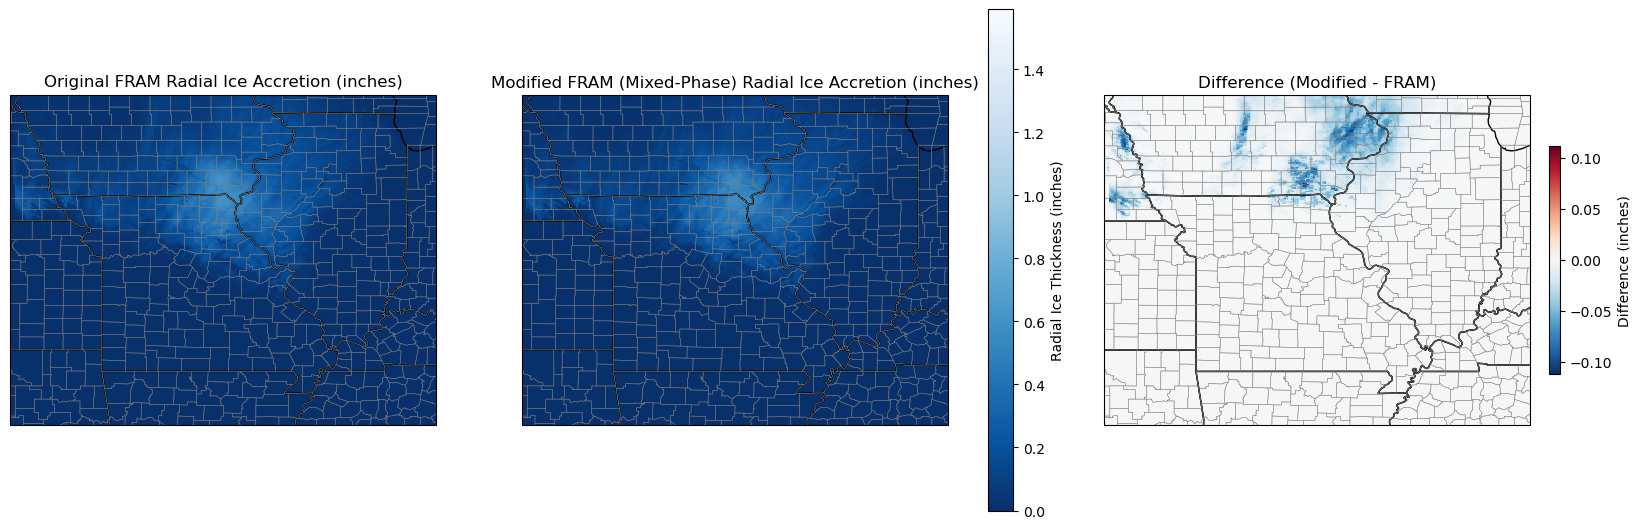

In [7]:
# FRAM vs. modified FRAM (radial)
radial_total = processed_ds.radial_ice_thickness_in_fram.isel(time=-1)
radial_mod_total = processed_ds.radial_ice_thickness_in_mod.isel(time=-1)

diff = radial_mod_total - radial_total
fig, axes = plt.subplots(1, 3, figsize=(20,7), subplot_kw={"projection": ccrs.PlateCarree()})
vmax = float(max(fram_total.max(), mod_total.max()))

# Original FRAM radial
mesh1 = axes[0].pcolormesh(lons, lats, radial_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
setup_map(axes[0])
axes[0].set_title("Original FRAM Radial Ice Accretion (inches)")
axes[0].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

# Modified FRAM radial
mesh2 = axes[1].pcolormesh(lons, lats, radial_mod_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
setup_map(axes[1])
axes[1].set_title("Modified FRAM (Mixed-Phase) Radial Ice Accretion (inches)")
axes[1].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

# Difference
# symmetric color scale centered at 0
diff_max = float(np.abs(diff).max())
mesh3 = axes[2].pcolormesh(lons, lats, diff, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-diff_max, vmax=diff_max)
setup_map(axes[2])
axes[2].set_title("Difference (Modified - FRAM)")
axes[2].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

cbar1 = fig.colorbar(mesh1, ax=axes[:2], orientation="vertical", fraction=0.025, pad=0.04)
cbar1.set_label("Radial Ice Thickness (inches)")
cbar2 = fig.colorbar(mesh3, ax=axes[2], orientation="vertical", fraction=0.025, pad=0.04)
cbar2.set_label("Difference (inches)")
plt.show()

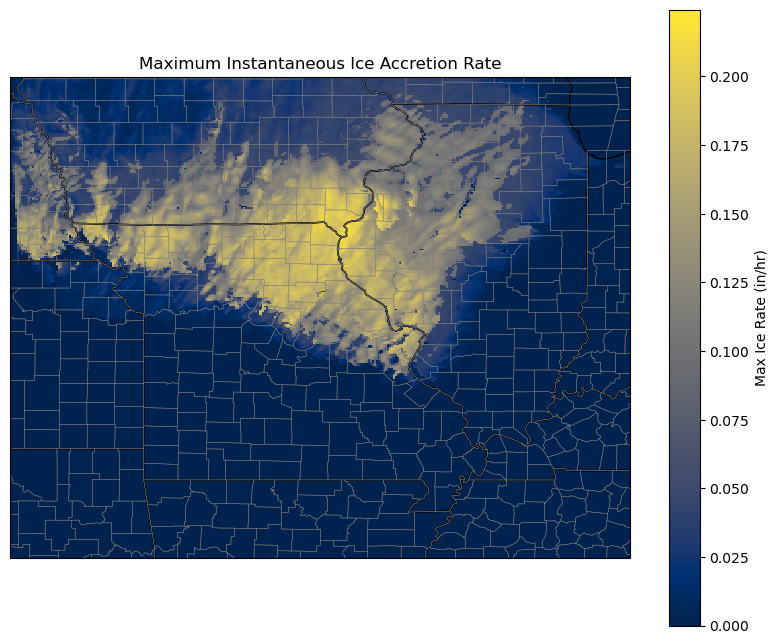

In [8]:
# Maximum Instantaneous Ice Accretion Rate (in/hr)
max_rate = processed_ds.ice_rate_in_hr_mod.max(dim="time")

plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lons, lats, max_rate, transform=ccrs.PlateCarree(), cmap="cividis")
setup_map(ax)
ax.set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())
plt.colorbar(mesh, label="Max Ice Rate (in/hr)")
plt.title("Maximum Instantaneous Ice Accretion Rate")
plt.show()

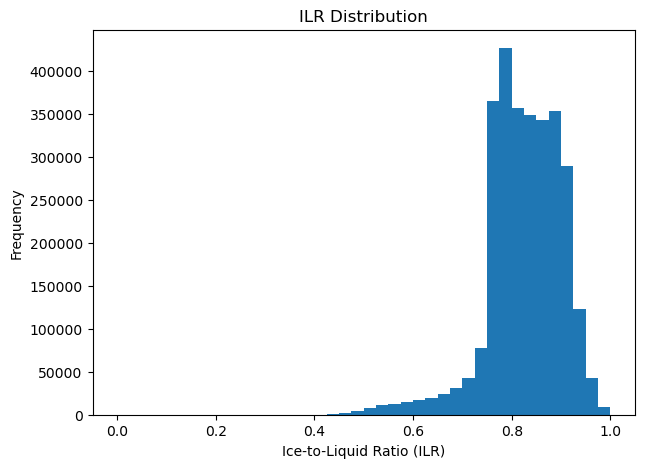

In [9]:
# ILR Distribution (only freezing gridpoints)
ilr_vals = processed_ds.ILR.where(processed_ds.wetbulb <= 0).values.flatten()
ilr_vals = ilr_vals[~np.isnan(ilr_vals)]

plt.figure(figsize=(7,5))
plt.hist(ilr_vals, bins=40)
plt.xlabel("Ice-to-Liquid Ratio (ILR)")
plt.ylabel("Frequency")
plt.title("ILR Distribution")
plt.show()

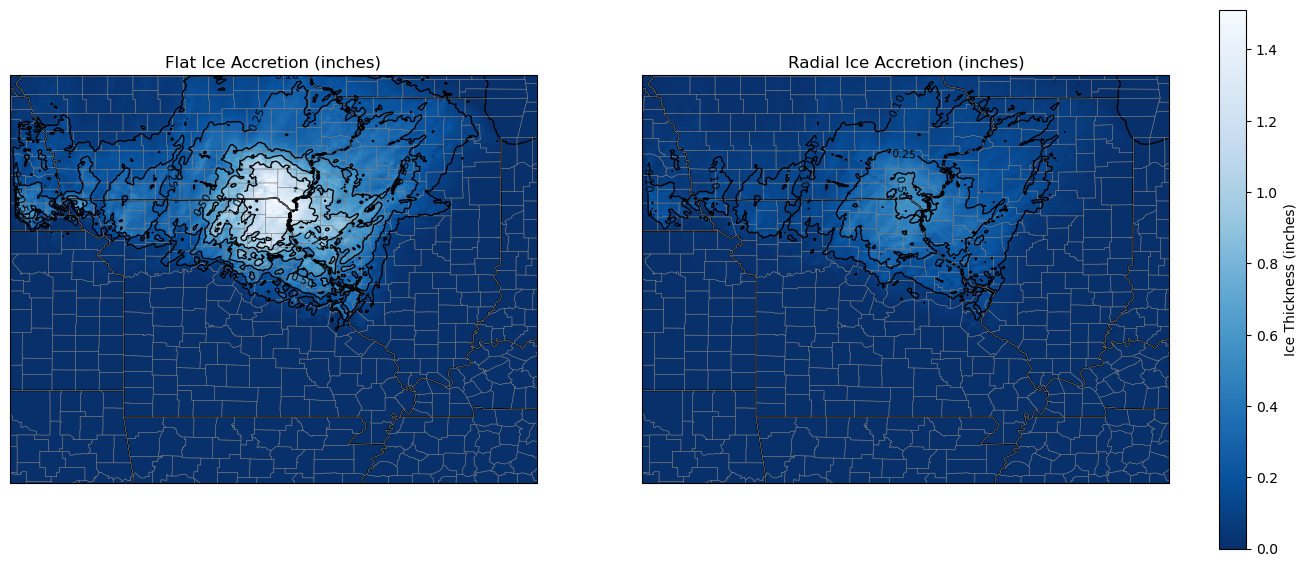

In [10]:
# Ice Thickness Contours (Final Time)
radial_mod_total = processed_ds.radial_ice_thickness_in_mod.isel(time=-1)

levels = [0.1, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(16,7), subplot_kw={"projection": ccrs.PlateCarree()})
vmax = float(max(mod_total.max(), radial_mod_total.max()))

# Flat Ice
mesh1 = axes[0].pcolormesh(lons, lats, mod_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
contours1 = axes[0].contour(lons, lats, mod_total, levels=levels, colors="black", linewidths=1, transform=ccrs.PlateCarree())
axes[0].clabel(contours1, inline=True, fontsize=8)
setup_map(axes[0])
axes[0].set_title("Flat Ice Accretion (inches)")
axes[0].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

# Radial Ice
mesh2 = axes[1].pcolormesh(lons, lats, radial_mod_total, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=0, vmax=vmax)
contours2 = axes[1].contour(lons, lats, radial_mod_total, levels=levels, colors="black", linewidths=1, transform=ccrs.PlateCarree())
axes[1].clabel(contours2, inline=True, fontsize=8)
setup_map(axes[1])
axes[1].set_title("Radial Ice Accretion (inches)")
axes[1].set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

cbar = fig.colorbar(mesh1, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
cbar.set_label("Ice Thickness (inches)")
plt.show()

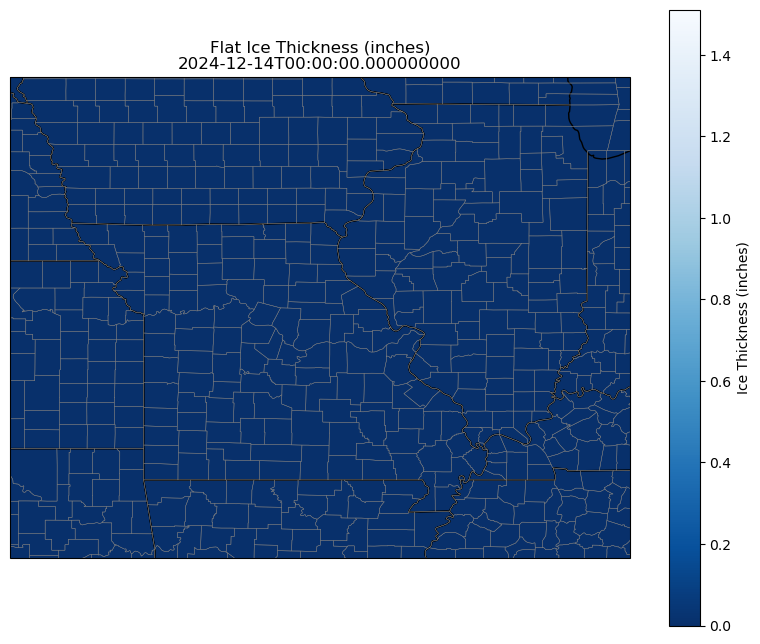

In [11]:
# ice thickness animation with stagnant colorbar

fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
setup_map(ax)
vmax = float(processed_ds.ice_thickness_in_mod.max())
vmin = 0

# initial frame
data = processed_ds.ice_thickness_in_mod.isel(time=0)
mesh = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=vmin, vmax=vmax)
ax.set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())
cbar = plt.colorbar(mesh, ax=ax, label="Ice Thickness (inches)")

def update(t):
    data = processed_ds.ice_thickness_in_mod.isel(time=t)
    # update mesh values instead of recreating
    mesh.set_array(data.values.ravel())
    ax.set_title(f"Flat Ice Thickness (inches)\n{str(processed_ds.time.values[t])}")

ani = animation.FuncAnimation(fig, update, frames=len(processed_ds.time), interval=200)
ani.save("ice_thickness_animation.gif", writer="pillow", dpi=150)
ani.save("ice_thickness_animation.mp4", dpi=200, writer="ffmpeg")

In [12]:
reports = [
("Cedar Rapids Arpt", 0.68),
("2 SE Coralville", 0.50),
("3 NNE Cedar Rapids", 0.50),
("North Liberty", 0.50),
("Anamosa", 0.45),
("Marion", 0.42),
("Colchester", 0.40),
("Industry", 0.40),
("2 N Ely", 0.40),
("Parnell", 0.40),
("2 S Hiawatha", 0.40),
("2 N Central City", 0.40),
("1 ESE Solon", 0.38),
("1 NNE Oakdale", 0.38),
("Tiffin", 0.38),
("Manchester", 0.38),
("1 WNW Cou Falls", 0.37),
("2 ENE Hiawatha", 0.35),
("1 W Elmira", 0.35),
("1 SSW Washington", 0.32),
("Davenport Arpt", 0.32),
("Iowa City", 0.30),
("1 ENE Fairfax", 0.30),
("2 ESE Iowa City", 0.30),
("2 NE Cedar Rapids", 0.30),
("3 N Marion", 0.30),
("Stanwood", 0.30),
("Lowden", 0.30),
("Quad City Intl Arpt", 0.27),
("Dubuque Arpt", 0.26),
("1 NE Cedar Rapids", 0.25),
("Columbus City", 0.25),
("Carthage", 0.25),
("Cedar Rapids", 0.25),
("1 ENE North English", 0.25),
("2 E Cedar Rapids", 0.25),
("4 S Atkins", 0.25),
("1 SSW Mooar", 0.25),
("1 NE Spring Grove", 0.25),
("1 W Amana", 0.25),
("1 WNW Sigourney", 0.25),
("3 SW Yarmouth", 0.25),
("Riverside", 0.25),
("2 SW Sunbury", 0.25),
("Upper South Amana", 0.25),
("1 ENE Silvis", 0.25),
("1 SW Silvis", 0.25),
("2 NNE Iowa City", 0.25),
("Winfield", 0.25),
("Washington", 0.25),
("1 SSW Cordova", 0.24),
("3 ENE Charlie Heath Memorial", 0.20),
("2 SSE Burlington Regional Ai", 0.20),
("1 SW Perlee", 0.20),
("1 W Macomb", 0.20),
("3 W Mount Sterling", 0.20),
("1 ENE Burlington Regional Ai", 0.20),
("1 NE Iowa City", 0.20),
("1 W Industry", 0.20),
("2 S Coggon", 0.20),
("2 NNE New Windsor", 0.20),
("2 WNW Bettendorf", 0.20),
("2 ENE Hazleton", 0.20),
("1 SSW Coal Valley", 0.19),
("1 SSW Montrose", 0.16),
("Urbana", 0.15),
("1 SE Sand Hill", 0.13),
("2 NNE Muscatine", 0.13),
("1 NE Park View", 0.13),
("1 NNW Dewitt", 0.13),
("1 ENE Clinton", 0.13),
("Robins", 0.10),
("1 NW Center Grove", 0.10),
("Wyoming", 0.10),
("2 SSE Warner", 0.10),
("Bushnell", 0.10),
("Davis", 0.10),
("Rubio", 0.00),
("1 ENE Clinton (2)", 0.00),
("Cambridge", 0.00),
("Macomb", 0.00),
]

obs_df = pd.DataFrame(reports, columns=["location","ice_in"])

In [13]:
coords = {
"Cedar Rapids Arpt": (41.884, -91.710),
"2 SE Coralville": (41.665, -91.540),
"3 NNE Cedar Rapids": (42.010, -91.650),
"North Liberty": (41.749, -91.597),
"Anamosa": (42.108, -91.285),
"Marion": (42.035, -91.596),
"2 N Ely": (41.920, -91.580),
"Parnell": (41.583, -91.572),
"2 S Hiawatha": (41.985, -91.670),
"2 N Central City": (42.230, -91.530),
"1 ESE Solon": (41.805, -91.470),
"1 NNE Oakdale": (41.705, -91.600),
"Tiffin": (41.706, -91.662),
"1 W Elmira": (41.610, -91.540),
"1 SSW Washington": (41.285, -91.700),
"Iowa City": (41.661, -91.530),
"1 ENE Fairfax": (41.925, -91.770),
"2 ESE Iowa City": (41.640, -91.490),
"2 NE Cedar Rapids": (41.990, -91.650),
"3 N Marion": (42.080, -91.590),
"Stanwood": (41.888, -91.153),
"Lowden": (41.860, -90.920),
"1 NE Cedar Rapids": (41.990, -91.650),
"Columbus City": (41.290, -91.360),
"Cedar Rapids": (41.977, -91.665),
"1 ENE North English": (41.520, -92.070),
"2 E Cedar Rapids": (41.980, -91.620),
"4 S Atkins": (41.950, -91.860),
"1 SSW Mooar": (41.680, -92.000),
"1 W Amana": (41.800, -91.900),
"1 WNW Sigourney": (41.330, -92.210),
"Riverside": (41.480, -91.580),
"Upper South Amana": (41.800, -91.870),
"2 NNE Iowa City": (41.690, -91.520),
"Winfield": (41.130, -91.430),
"Washington": (41.301, -91.692),
"1 SSW Cordova": (41.680, -90.320),
"3 ENE Charlie Heath Memorial": (41.420, -91.030),
"2 SSE Burlington Regional Ai": (40.760, -91.130),
"1 NE Iowa City": (41.690, -91.520),
"1 W Industry": (40.330, -90.600),
"2 S Coggon": (42.250, -91.530),
"2 ENE Hazleton": (42.620, -91.900),
"1 SSW Montrose": (40.520, -91.420),
"Urbana": (42.224, -91.871),
"1 SE Sand Hill": (41.100, -90.850),
"2 NNE Muscatine": (41.470, -91.020),
"1 NE Park View": (41.700, -90.560),
"1 NNW Dewitt": (41.840, -90.540),
"1 ENE Clinton": (41.850, -90.170),
"Robins": (42.070, -91.670),
"1 NW Center Grove": (41.980, -90.250),
"Wyoming": (42.060, -91.010),
"2 SSE Warner": (41.550, -91.230),
"Colchester": (40.425, -90.790),
"Industry": (40.325, -90.600),
"Manchester": (39.545, -90.330),
"1 WNW Cou Falls": (41.600, -90.250),
"1 W Macomb": (40.460, -90.700),
"3 W Mount Sterling": (39.990, -90.850),
"1 SW Perlee": (40.200, -91.100),
"3 SW Yarmouth": (40.350, -91.000),
"2 SW Sunbury": (41.600, -90.900),
"1 ENE Silvis": (41.510, -90.390),
"1 SW Silvis": (41.500, -90.410),
"2 NNE New Windsor": (41.230, -90.470),
"2 WNW Bettendorf": (41.560, -90.560),
"1 SSW Coal Valley": (41.420, -90.460),
"Bushnell": (40.550, -90.500),
"Davis": (42.430, -89.420),
"Cambridge": (41.300, -90.200),
"Macomb": (40.460, -90.670),
"Quad City Intl Arpt": (41.448, -90.507),
"Dubuque Arpt": (42.402, -90.709),
"Davenport Arpt": (41.610, -90.588),
"Rubio": (41.660, -92.030),
"1 ENE Clinton (2)": (41.850, -90.170)
}

obs_df["lat"] = obs_df["location"].map(lambda x: coords.get(x, (None, None))[0])
obs_df["lon"] = obs_df["location"].map(lambda x: coords.get(x, (None, None))[1])

In [14]:
missing = obs_df[obs_df["lat"].isna()]
print(missing["location"])

17                  2 ENE Hiawatha
32                        Carthage
38               1 NE Spring Grove
56    1 ENE Burlington Regional Ai
Name: location, dtype: str


In [15]:
buffer = 0.3

lon_min = obs_df.lon.min() - buffer
lon_max = obs_df.lon.max() + buffer
lat_min = obs_df.lat.min() - buffer
lat_max = obs_df.lat.max() + buffer

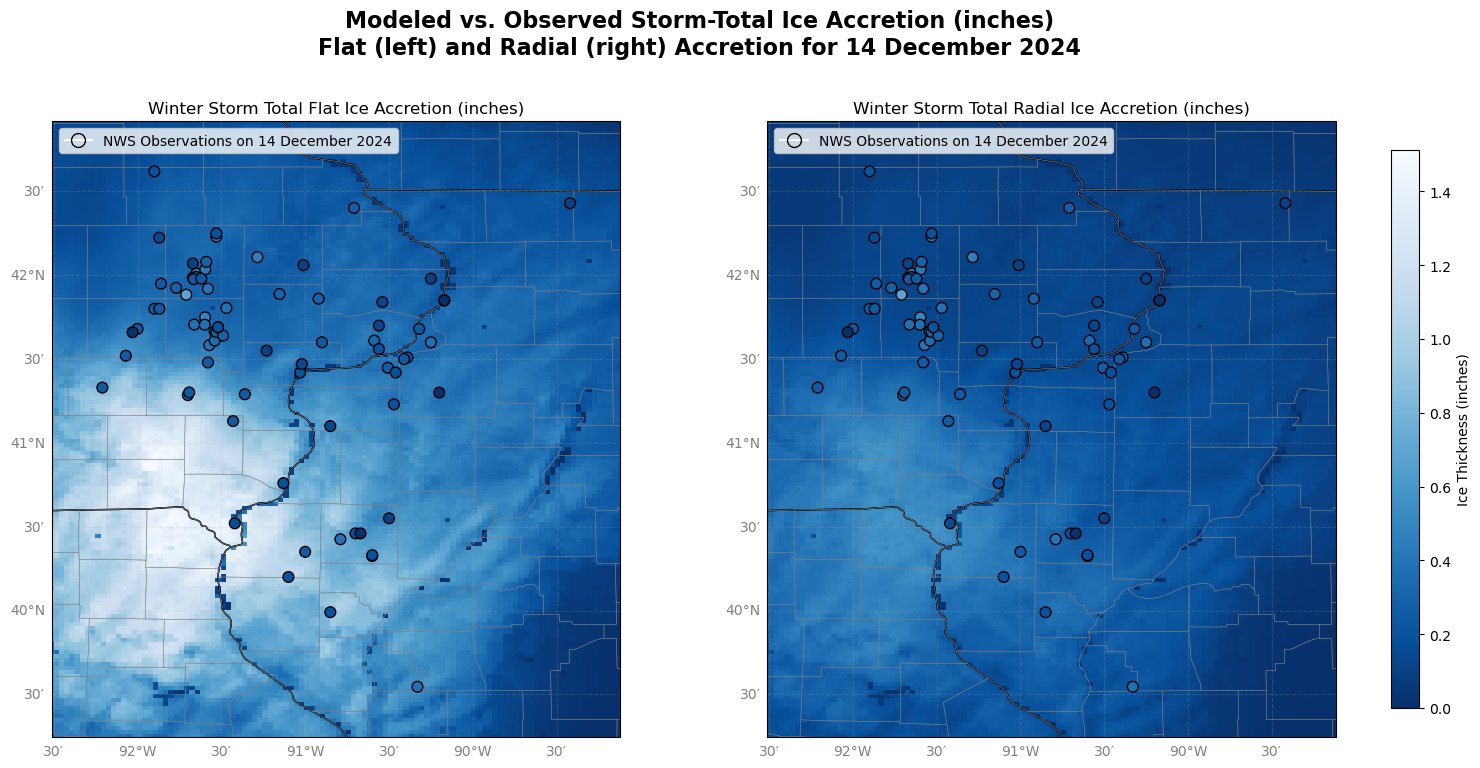

In [16]:
# Storm total ice accumulation with observations
import matplotlib as mpl

vmax = float(max(mod_total.max(), radial_mod_total.max(), obs_df.ice_in.max())) # shared color scale
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={"projection": ccrs.PlateCarree()})

for ax in axes:
    setup_map(ax)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.2, linestyle='--')
    gl.top_labels = False  
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Flat Ice (Modified FRAM)
axes[0].set_title("Winter Storm Total Flat Ice Accretion (inches)")
mesh1 = axes[0].pcolormesh(lons, lats, mod_total, transform=ccrs.PlateCarree(), cmap="Blues_r", norm=norm)
sc1 = axes[0].scatter(obs_df.lon, obs_df.lat, c=obs_df.ice_in, cmap="Blues_r", norm=norm, edgecolor="black", s=60, transform=ccrs.PlateCarree(), zorder=5)

# Radial Ice (Modified FRAM)
axes[1].set_title("Winter Storm Total Radial Ice Accretion (inches)")
mesh2 = axes[1].pcolormesh(lons, lats, radial_mod_total, transform=ccrs.PlateCarree(), cmap="Blues_r", norm=norm)
sc2 = axes[1].scatter(obs_df.lon, obs_df.lat, c=obs_df.ice_in, cmap="Blues_r", norm=norm, edgecolor="black", s=60, transform=ccrs.PlateCarree(), zorder=5)

# Legend for observation points
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='NWS Observations on 14 December 2024', markerfacecolor='none', markeredgecolor='black', markersize=10)]
axes[0].legend(handles=legend_elements, loc='upper left', frameon=True)
axes[1].legend(handles=legend_elements, loc='upper left', frameon=True)

fig.suptitle(
    "Modeled vs. Observed Storm-Total Ice Accretion (inches)\n"
    "Flat (left) and Radial (right) Accretion for 14 December 2024",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# Shared colorbar 
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap="Blues_r"), ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Ice Thickness (inches)")

plt.show()

# Caption
Figure X. Comparison of storm-total ice accretion (inches) for the 14 December 2024 winter storm. Shaded contours represent accretion simulated by a WRF-ARW ensemble member, displaying (left) flat ice and (right) radial ice formulations. Overlaid circles represent National Weather Service (NWS) surface observations, plotted on the same color scale (0.0 to 1.5 inches) to illustrate spatial biases in the ensemble's ice placement and magnitude. The model captures the broad footprint of the storm across the mid-Mississippi Valley.

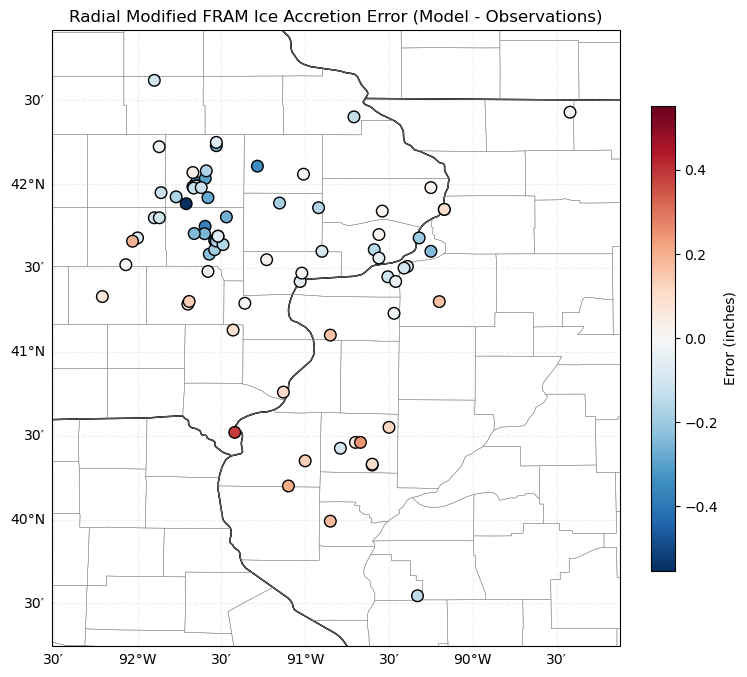

In [21]:
# radial model - observation error
lats2d = radial_mod_total.XLAT.values
lons2d = radial_mod_total.XLONG.values
model_grid = radial_mod_total.values
model_at_obs = []

for lon, lat in zip(obs_df.lon.values, obs_df.lat.values):
    dist = (lats2d - lat)**2 + (lons2d - lon)**2 # Distance in lat/lon space
    iy, ix = np.unravel_index(np.argmin(dist), dist.shape) # Find nearest grid point
    model_at_obs.append(model_grid[iy, ix])
model_at_obs = np.array(model_at_obs)

error = model_at_obs - obs_df.ice_in.values
err_max = np.max(np.abs(error))
norm = mpl.colors.Normalize(vmin=-err_max, vmax=err_max)

fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
setup_map(ax)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.2, linestyle='--')
gl.top_labels = False
gl.right_labels = False
sc = ax.scatter(obs_df.lon, obs_df.lat, c=error, cmap="RdBu_r", norm=norm, edgecolor="black", s=70, transform=ccrs.PlateCarree(), zorder=5)

ax.set_title("Radial Modified FRAM Ice Accretion Error (Model - Observations)")
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap="RdBu_r"), ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Error (inches)")

plt.show()